In [ ]:
import pandas as pd
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

# Load saved results

RESULTS_PATH = Path("..") / ".." / ".." / "eca" / "notebooks" / "RQ2" / "results"

In [32]:
# Load metrics

with open(RESULTS_PATH / "logistic_regression.json") as f:
    lr_full = json.load(f)

with open(RESULTS_PATH / "lr_subsets.json") as f:
    lr_subsets = json.load(f)

with open(RESULTS_PATH / "rf_metrics.json") as f:
    rf = json.load(f)

In [33]:
comparison_df = pd.DataFrame([
    {"Model": "Logistic Regression (Full)", **lr_full},
    {"Model": "LR (Top Predictors)", **lr_subsets["top_predictors"]},
    {"Model": "LR (Workplace)", **lr_subsets["workplace"]},
    {"Model": "LR (Demographics)", **lr_subsets["demographics"]},
    {"Model": "Random Forest", **rf}
])

comparison_df

,Model,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (Full),Logistic Regression (Tuned),0.785714,0.778626,0.803150,0.790698,0.872945
1,LR (Top Predictors),LR (Top Predictors),0.773810,0.761194,0.803150,0.781609,0.862079
2,LR (Workplace),LR (Workplace Subset),0.626984,0.643478,0.582677,0.611570,0.666929
3,LR (Demographics),LR (Demographics Subset),0.619048,0.618321,0.637795,0.627907,0.630583
4,Random Forest,Random Forest (Tuned),0.837302,0.802817,0.897638,0.847584,0.885921


In [ ]:
# Save metrics comparison

comparison_df.to_csv(
    RESULTS_PATH / "comparison_metrics.csv",
    index=False
)

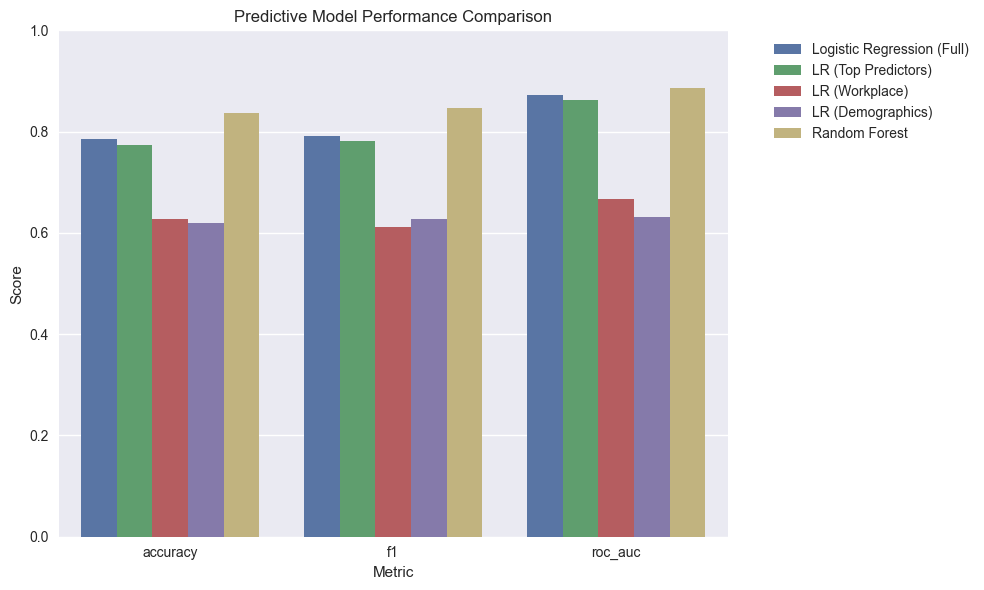

In [ ]:
# Performance comparison plot
# Accuracy, F1 Score, ROC-AUC

metrics = ["accuracy", "f1", "roc_auc"]

long_df = comparison_df.melt(
    id_vars="Model",
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=long_df,
    x="Metric",
    y="Score",
    hue="Model"
)
plt.ylim(0, 1)
plt.title("Predictive Model Performance Comparison")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
# Confusion matrix comparison plot (LR full vs RF)

# LR = balanced, RF = higher recall

# Use saved predictions if available; otherwise show previously generated figures


In [ ]:
# ROC-AUC comparison plot (LR full vs RF)

# Narrative focus:
	# •	Both have strong discrimination
	# •	RF slightly higher AUC
	# •	RF better separation at low false-positive rates

In [40]:
lr_coef = pd.read_csv(RESULTS_PATH / "lr_full_coefficients.csv")
rf_imp = pd.read_csv(RESULTS_PATH / "rf_feature_importance.csv")